# Experiment 04 — FedProx under Statistical Heterogeneity

This notebook evaluates FedProx in the severe Dirichlet label-skew setting established in Experiment 03.


## 1. Research Question

Experiment 03 established a controlled Dirichlet heterogeneity setting for FedAvg. This experiment asks whether proximal regularization improves federated optimization under severe statistical heterogeneity, and how sensitive performance is to the proximal coefficient $\mu$.


## 2. Experimental Design

The comparison holds fixed MNIST, `SimpleMLP`, preprocessing, the initial checkpoint $w_0$, the `alpha=0.1` client partition, optimizer, learning rate, batch size, full client participation, number of communication rounds, and local epochs.

The only experimental variable is $\mu$:

$$
\mu \in \{0, 0.001, 0.01, 0.1, 1.0\}.
$$

FedAvg optimizes each client objective $F_k(w)$. FedProx uses the local objective

$$
F_k(w) + \frac{\mu}{2}\lVert w - w_t \rVert_2^2,
$$

where $w_t$ is the round-start global model. The $\mu=0$ condition is the FedAvg-equivalent control.


## 3. Setup


In [3]:
from pathlib import Path
import os
import sys


def find_repo_root():
    """Find the repository root from VS Code, Kaggle, or Colab."""
    cwd = Path.cwd().resolve()

    candidates = [cwd, *cwd.parents]
    candidates += [
        Path("/kaggle/working/federated-learning-under-heterogeneity"),
        Path("/content/federated-learning-under-heterogeneity"),
    ]

    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()

    raise RuntimeError(
        "Repository root not found.\n"
        "Open the 'federated-learning-under-heterogeneity' folder in VS Code, "
        "or clone/cd into the repository before running this notebook."
    )


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root  :", REPO_ROOT)
print("Working dir:", Path.cwd())
print("Python     :", sys.executable)


Repo root  : /kaggle/working/federated-learning-under-heterogeneity
Working dir: /kaggle/working/federated-learning-under-heterogeneity
Python     : /usr/bin/python3


In [4]:
import copy
import json
import random
import time
from dataclasses import asdict, dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from src.models import SimpleMLP
from src.training import client_update, evaluate, federated_train
from src.data import client_label_counts, create_client_loaders
from src.fedprox import (
    client_update_fedprox,
    federated_train_fedprox,
    train_one_epoch_fedprox,
)
import src.fedprox as fedprox_module

print("src.fedprox loaded from:", fedprox_module.__file__)
print("Imports successful.")


src.fedprox loaded from: /kaggle/working/federated-learning-under-heterogeneity/src/fedprox.py
Imports successful.


### Implementation Map

This notebook contains experiment orchestration and analysis only.

Reusable code stays under `src/`:

- `src/models.py` — model definition;
- `src/data.py` — partitions, label counts, and client loaders;
- `src/training.py` — FedAvg client update, evaluation, and training loop;
- `src/fedprox.py` — FedProx local objective, client update, and training loop;
- `src/aggregate.py` — weighted server aggregation.


## 4. Configuration


In [5]:
@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42
    num_clients: int = 5

    alpha: float = 0.1
    mu_values: tuple = (0.0, 0.001, 0.01, 0.1, 1.0)

    local_epochs: int = 5
    num_rounds: int = 20
    batch_size: int = 64
    learning_rate: float = 0.01

    datasets_dir: str = "datasets"
    iid_results_dir: str = "results/iid_baseline"
    dirichlet_results_dir: str = "results/dirichlet_noniid"
    results_dir: str = "results/fedprox"


CFG = ExperimentConfig()

RESULT_DIR = REPO_ROOT / CFG.results_dir
ALPHA_RESULT_DIR = RESULT_DIR / f"alpha_{str(CFG.alpha).replace('.', 'p')}"
FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
ALPHA_RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with (RESULT_DIR / "config.json").open("w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(CFG)
print("Device :", device)
print("Results:", RESULT_DIR)


ExperimentConfig(seed=42, num_clients=5, alpha=0.1, mu_values=(0.0, 0.001, 0.01, 0.1, 1.0), local_epochs=5, num_rounds=20, batch_size=64, learning_rate=0.01, datasets_dir='datasets', iid_results_dir='results/iid_baseline', dirichlet_results_dir='results/dirichlet_noniid', results_dir='results/fedprox')
Device : cuda
Results: /kaggle/working/federated-learning-under-heterogeneity/results/fedprox


In [6]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_mnist(root):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])

    train_ds = datasets.MNIST(
        root=root,
        train=True,
        download=True,
        transform=transform,
    )

    test_ds = datasets.MNIST(
        root=root,
        train=False,
        download=True,
        transform=transform,
    )

    return train_ds, test_ds


def load_torch_object(path, map_location="cpu"):
    """Compatibility helper across PyTorch versions."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def alpha_tag(alpha: float) -> str:
    return f"{alpha:g}".replace(".", "p")


def mu_tag(mu: float) -> str:
    return f"{mu:g}".replace("-", "m").replace(".", "p")


def verify_partition(client_indices, dataset_size: int):
    flat = [
        int(idx)
        for indices in client_indices.values()
        for idx in indices
    ]

    checks = {
        "dataset_size": dataset_size,
        "assigned": len(flat),
        "unique": len(set(flat)),
        "all_clients_nonempty": all(len(indices) > 0 for indices in client_indices.values()),
    }

    if checks["assigned"] != dataset_size:
        raise ValueError("Partition lost or added examples.")

    if checks["unique"] != dataset_size:
        raise ValueError("Partition contains duplicate or missing indices.")

    if not checks["all_clients_nonempty"]:
        raise ValueError("At least one client is empty.")

    if min(flat) < 0 or max(flat) >= dataset_size:
        raise ValueError("Partition contains invalid dataset indices.")

    return checks


## 5. Load MNIST


In [7]:
set_seed(CFG.seed)

train_ds, test_ds = load_mnist(REPO_ROOT / CFG.datasets_dir)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
)

print("Training examples:", len(train_ds))
print("Test examples    :", len(test_ds))


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]

Training examples: 60000
Test examples    : 10000


## 6. Reuse Experiment 03 Partition

The severe heterogeneity condition is the saved `alpha=0.1` Dirichlet partition from Experiment 03. The partition is loaded rather than regenerated so FedAvg and FedProx are compared on the same client datasets.


In [8]:
DIRICHLET_ALPHA_DIR = REPO_ROOT / CFG.dirichlet_results_dir / f"alpha_{alpha_tag(CFG.alpha)}"
CLIENT_INDICES_PATH = DIRICHLET_ALPHA_DIR / "client_indices.pt"

if not CLIENT_INDICES_PATH.exists():
    raise FileNotFoundError(
        f"Missing Experiment 03 partition:\n{CLIENT_INDICES_PATH}"
    )

client_indices = load_torch_object(CLIENT_INDICES_PATH)
partition_checks = verify_partition(client_indices, len(train_ds))

print(partition_checks)
print("\nClient sizes:")
for client_id, indices in client_indices.items():
    print(f"Client {client_id}: {len(indices)} samples")


{'dataset_size': 60000, 'assigned': 60000, 'unique': 60000, 'all_clients_nonempty': True}

Client sizes:
Client 0: 8505 samples
Client 1: 8904 samples
Client 2: 13325 samples
Client 3: 21164 samples
Client 4: 8102 samples


In [9]:
source_distribution_path = DIRICHLET_ALPHA_DIR / "client_label_distribution.csv"

if source_distribution_path.exists():
    label_distribution_df = pd.read_csv(source_distribution_path)
else:
    label_distribution_df = client_label_counts(train_ds, client_indices)

fedprox_distribution_path = ALPHA_RESULT_DIR / "client_label_distribution.csv"
label_distribution_df.to_csv(fedprox_distribution_path, index=False)

digit_columns = [f"digit_{d}" for d in range(10)]
summary_columns = ["client", "samples", *digit_columns]
label_distribution_df[summary_columns]


,client,samples,digit_0,digit_1,digit_2,digit_3,digit_4,digit_5,digit_6,digit_7,digit_8,digit_9
0,0,8505,7,0,0,5526,16,0,15,756,2182,3
1,1,8904,0,91,627,11,2027,0,2306,0,3668,174
2,2,13325,79,0,5329,44,1625,0,3450,1,0,2797
3,3,21164,1721,6650,0,0,1950,5417,69,5357,0,0
4,4,8102,4116,1,2,550,224,4,78,151,1,2975


## 7. Controlled Initialization

Every run starts from the Experiment 01 initial checkpoint.


In [10]:
INITIAL_MODEL_PATH = REPO_ROOT / CFG.iid_results_dir / "initial_model.pt"

if not INITIAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing initial checkpoint:\n{INITIAL_MODEL_PATH}"
    )

initial_state = load_torch_object(INITIAL_MODEL_PATH)

initial_model = SimpleMLP(784, 10)
initial_model.load_state_dict(initial_state)
initial_model.to(device)

loss_fn = nn.CrossEntropyLoss()

initial_loss, initial_acc = evaluate(
    initial_model,
    test_loader,
    loss_fn,
    device,
)

print(f"Initial loss    : {initial_loss:.6f}")
print(f"Initial accuracy: {initial_acc:.4f}")

assert abs(initial_loss - 2.313339) < 1e-3
assert abs(initial_acc - 0.1267) < 1e-4


Initial loss    : 2.313339
Initial accuracy: 0.1267


## 8. FedProx Implementation Check

The FedProx implementation used below is imported from `src/fedprox.py`.


In [11]:
required_fedprox_functions = {
    "train_one_epoch_fedprox": train_one_epoch_fedprox,
    "client_update_fedprox": client_update_fedprox,
    "federated_train_fedprox": federated_train_fedprox,
}

for name, fn in required_fedprox_functions.items():
    if not callable(fn):
        raise TypeError(f"{name} is not callable")

pd.DataFrame({
    "module": ["src/fedprox.py"] * len(required_fedprox_functions),
    "function": list(required_fedprox_functions),
})


,module,function
0,src/fedprox.py,train_one_epoch_fedprox
1,src/fedprox.py,client_update_fedprox
2,src/fedprox.py,federated_train_fedprox


## 9. Correctness Validation

The checks below use real model updates on small deterministic subsets. They validate behavior without running the full experiment.


In [12]:
def fresh_initial_model():
    model = SimpleMLP(784, 10)
    model.load_state_dict(copy.deepcopy(initial_state))
    model.to(device)
    return model


def make_capped_client_loaders(max_examples_per_client: int = 128, shuffle: bool = False):
    loaders = {}

    for client_id, indices in client_indices.items():
        capped_indices = list(indices)[:max_examples_per_client]
        loaders[client_id] = DataLoader(
            Subset(train_ds, capped_indices),
            batch_size=min(CFG.batch_size, max_examples_per_client),
            shuffle=shuffle,
        )

    return loaders


def max_parameter_difference(model_a, model_b):
    diffs = []

    for param_a, param_b in zip(model_a.parameters(), model_b.parameters()):
        diffs.append(
            (param_a.detach().cpu() - param_b.detach().cpu()).abs().max().item()
        )

    return max(diffs) if diffs else 0.0


validation_loaders = make_capped_client_loaders(max_examples_per_client=128, shuffle=False)
first_client_id = sorted(validation_loaders)[0]
first_loader = validation_loaders[first_client_id]

print("Validation client:", first_client_id)
print("Validation examples:", len(first_loader.dataset))


Validation client: 0
Validation examples: 128


In [13]:
global_model = fresh_initial_model()
before_update_state = {
    name: tensor.detach().cpu().clone()
    for name, tensor in global_model.state_dict().items()
}

_ = client_update_fedprox(
    global_model=global_model,
    client_loader=first_loader,
    local_epochs=1,
    learning_rate=CFG.learning_rate,
    loss_fn=nn.CrossEntropyLoss(),
    device=device,
    mu=0.1,
)

after_update_state = {
    name: tensor.detach().cpu()
    for name, tensor in global_model.state_dict().items()
}

immutability_ok = all(
    torch.equal(before_update_state[name], after_update_state[name])
    for name in before_update_state
)

assert immutability_ok
print("Global-model immutability check passed.")


Global-model immutability check passed.


In [14]:
set_seed(CFG.seed)
fedavg_reference = client_update(
    global_model=fresh_initial_model(),
    client_loader=first_loader,
    local_epochs=1,
    learning_rate=CFG.learning_rate,
    loss_fn=nn.CrossEntropyLoss(),
    device=device,
)

set_seed(CFG.seed)
fedprox_mu0 = client_update_fedprox(
    global_model=fresh_initial_model(),
    client_loader=first_loader,
    local_epochs=1,
    learning_rate=CFG.learning_rate,
    loss_fn=nn.CrossEntropyLoss(),
    device=device,
    mu=0.0,
)

mu0_max_diff = max_parameter_difference(fedavg_reference, fedprox_mu0)

print(f"Maximum parameter difference: {mu0_max_diff:.3e}")
assert mu0_max_diff < 1e-7


Maximum parameter difference: 0.000e+00


In [15]:
_, smoke_history = federated_train_fedprox(
    global_model=fresh_initial_model(),
    client_loaders=validation_loaders,
    num_rounds=2,
    local_epochs=1,
    learning_rate=CFG.learning_rate,
    loss_fn=nn.CrossEntropyLoss(),
    test_loader=test_loader,
    device=device,
    mu=0.01,
    verbose=False,
)

required_history_columns = {"round", "test_loss", "test_accuracy", "mu"}

assert required_history_columns.issubset(smoke_history.columns)
assert smoke_history["round"].astype(int).tolist() == [0, 1, 2]
assert np.isfinite(smoke_history["test_loss"]).all()
assert np.isfinite(smoke_history["test_accuracy"]).all()

smoke_history


,round,test_loss,test_accuracy,mu
0,0,2.313339,0.1267,0.01
1,1,2.290029,0.1576,0.01
2,2,2.271333,0.1865,0.01


## 10. Experiment Runner

Each run rebuilds the model from the same $w_0$, uses the same `alpha=0.1` partition, and saves its history immediately after completion.


In [16]:
client_loaders = create_client_loaders(
    train_ds,
    client_indices,
    batch_size=CFG.batch_size,
)


def mu_result_dir(mu: float) -> Path:
    return ALPHA_RESULT_DIR / f"mu_{mu_tag(mu)}"


def history_path_for_mu(mu: float) -> Path:
    return mu_result_dir(mu) / "history.csv"


def validate_history(history: pd.DataFrame, num_rounds: int):
    required_columns = {"round", "test_loss", "test_accuracy", "mu"}

    if not required_columns.issubset(history.columns):
        missing = required_columns.difference(history.columns)
        raise ValueError(f"History is missing columns: {missing}")

    expected_rounds = list(range(num_rounds + 1))
    actual_rounds = history["round"].astype(int).tolist()

    if actual_rounds != expected_rounds:
        raise ValueError(f"Expected rounds 0..{num_rounds}, got {actual_rounds}")

    if abs(float(history.iloc[0]["test_loss"]) - initial_loss) > 1e-3:
        raise ValueError("History does not begin from the common initial loss.")

    if abs(float(history.iloc[0]["test_accuracy"]) - initial_acc) > 1e-4:
        raise ValueError("History does not begin from the common initial accuracy.")

    return history


def run_one_mu(mu: float, overwrite_existing: bool = False, verbose: bool = True):
    run_dir = mu_result_dir(mu)
    run_dir.mkdir(parents=True, exist_ok=True)
    history_path = history_path_for_mu(mu)

    if history_path.exists() and not overwrite_existing:
        history = pd.read_csv(history_path)
        return validate_history(history, CFG.num_rounds), 0.0, "loaded"

    set_seed(CFG.seed)
    model = fresh_initial_model()

    start = time.perf_counter()
    _, history = federated_train_fedprox(
        global_model=model,
        client_loaders=client_loaders,
        num_rounds=CFG.num_rounds,
        local_epochs=CFG.local_epochs,
        learning_rate=CFG.learning_rate,
        loss_fn=nn.CrossEntropyLoss(),
        test_loader=test_loader,
        device=device,
        mu=mu,
        verbose=verbose,
    )
    runtime = time.perf_counter() - start

    history = validate_history(history, CFG.num_rounds).copy()
    history["alpha"] = CFG.alpha
    history["local_epochs"] = CFG.local_epochs
    history["runtime_seconds"] = runtime
    history.to_csv(history_path, index=False)

    return history, runtime, "ran"


## 11. Mu Sweep


In [17]:
RUN_FULL_SWEEP = True
OVERWRITE_EXISTING = False

if RUN_FULL_SWEEP:
    for mu in CFG.mu_values:
        history, runtime, status = run_one_mu(
            mu=mu,
            overwrite_existing=OVERWRITE_EXISTING,
            verbose=True,
        )
        print(
            f"mu={mu:g}: {status}, "
            f"final_acc={history.iloc[-1]['test_accuracy']:.4f}, "
            f"runtime={runtime:.1f}s"
        )
else:
    print("Full mu sweep skipped. Set RUN_FULL_SWEEP=True to execute it.")


Round  1/20 | mu=0 | loss=1.5819 | acc=0.4011
Round  2/20 | mu=0 | loss=1.0738 | acc=0.6215
Round  3/20 | mu=0 | loss=0.8352 | acc=0.7035
Round  4/20 | mu=0 | loss=0.7061 | acc=0.7529
Round  5/20 | mu=0 | loss=0.5971 | acc=0.7954
Round  6/20 | mu=0 | loss=0.5827 | acc=0.7991
Round  7/20 | mu=0 | loss=0.5183 | acc=0.8261
Round  8/20 | mu=0 | loss=0.4857 | acc=0.8372
Round  9/20 | mu=0 | loss=0.4819 | acc=0.8399
Round 10/20 | mu=0 | loss=0.4638 | acc=0.8461
Round 11/20 | mu=0 | loss=0.4822 | acc=0.8396
Round 12/20 | mu=0 | loss=0.4575 | acc=0.8488
Round 13/20 | mu=0 | loss=0.4527 | acc=0.8507
Round 14/20 | mu=0 | loss=0.4365 | acc=0.8573
Round 15/20 | mu=0 | loss=0.4257 | acc=0.8597
Round 16/20 | mu=0 | loss=0.4236 | acc=0.8600
Round 17/20 | mu=0 | loss=0.4224 | acc=0.8619
Round 18/20 | mu=0 | loss=0.3998 | acc=0.8697
Round 19/20 | mu=0 | loss=0.3982 | acc=0.8704
Round 20/20 | mu=0 | loss=0.4073 | acc=0.8660
mu=0: ran, final_acc=0.8660, runtime=1277.8s
Round  1/20 | mu=0.001 | loss=1.578

## 12. Load Existing Results

Analysis cells load saved histories when they exist, so the notebook can be resumed without rerunning completed experiments.


In [18]:
def load_available_histories():
    histories = {}

    for mu in CFG.mu_values:
        history_path = history_path_for_mu(mu)

        if not history_path.exists():
            continue

        history = pd.read_csv(history_path)

        try:
            history = validate_history(history, CFG.num_rounds)
        except ValueError as exc:
            print(f"Skipping mu={mu:g}: {exc}")
            continue

        histories[mu] = history

    return histories


histories = load_available_histories()

if histories:
    print("Loaded mu values:", [f"{mu:g}" for mu in sorted(histories)])
else:
    print("No completed FedProx histories found yet.")


Loaded mu values: ['0', '0.001', '0.01', '0.1', '1']


## 13. Summary Metrics


In [19]:
def first_round_at_accuracy(history, threshold):
    hit = history.loc[
        history["test_accuracy"] >= threshold,
        "round",
    ]

    return int(hit.iloc[0]) if len(hit) else np.nan


summary_rows = []

for mu, history in histories.items():
    runtime = (
        float(history["runtime_seconds"].dropna().max())
        if "runtime_seconds" in history.columns and history["runtime_seconds"].notna().any()
        else np.nan
    )

    summary_rows.append({
        "mu": mu,
        "alpha": CFG.alpha,
        "local_epochs": CFG.local_epochs,
        "final_loss": float(history.iloc[-1]["test_loss"]),
        "final_accuracy": float(history.iloc[-1]["test_accuracy"]),
        "round_to_50": first_round_at_accuracy(history, 0.50),
        "round_to_70": first_round_at_accuracy(history, 0.70),
        "round_to_80": first_round_at_accuracy(history, 0.80),
        "round_to_90": first_round_at_accuracy(history, 0.90),
        "runtime_seconds": runtime,
    })

summary_df = pd.DataFrame(summary_rows)

if len(summary_df):
    summary_df = summary_df.sort_values("mu").reset_index(drop=True)
    summary_df.to_csv(RESULT_DIR / "summary.csv", index=False)
    display(summary_df)
else:
    print("No completed histories are available for summary.")


,mu,alpha,local_epochs,final_loss,final_accuracy,round_to_50,round_to_70,round_to_80,round_to_90,runtime_seconds
0,0.000,0.1,5,0.407260,0.8660,2,3,7,NaN,1277.800496
1,0.001,0.1,5,0.406731,0.8660,2,3,6,NaN,1285.861328
2,0.010,0.1,5,0.402684,0.8676,2,3,5,NaN,1284.683993
3,0.100,0.1,5,0.405571,0.8672,2,3,5,NaN,1259.880569
4,1.000,0.1,5,0.506573,0.8373,2,5,8,NaN,1266.742425


## 14. Accuracy vs Communication Round


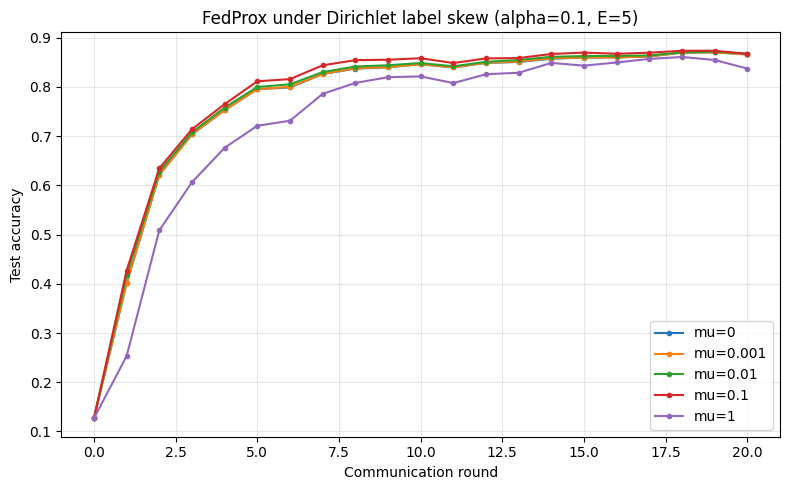

In [20]:
if histories:
    fig, ax = plt.subplots(figsize=(8, 5))

    for mu in sorted(histories):
        history = histories[mu]
        ax.plot(
            history["round"],
            history["test_accuracy"],
            marker="o",
            markersize=3,
            label=f"mu={mu:g}",
        )

    ax.set_xlabel("Communication round")
    ax.set_ylabel("Test accuracy")
    ax.set_title(f"FedProx under Dirichlet label skew (alpha={CFG.alpha:g}, E={CFG.local_epochs})")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "accuracy_vs_round_mu_sweep.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Run or restore at least one FedProx history first.")


## 15. Loss vs Communication Round


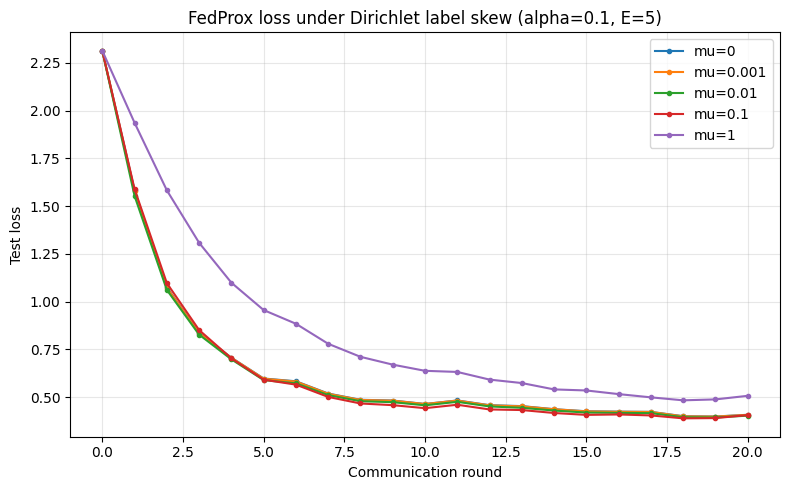

In [21]:
if histories:
    fig, ax = plt.subplots(figsize=(8, 5))

    for mu in sorted(histories):
        history = histories[mu]
        ax.plot(
            history["round"],
            history["test_loss"],
            marker="o",
            markersize=3,
            label=f"mu={mu:g}",
        )

    ax.set_xlabel("Communication round")
    ax.set_ylabel("Test loss")
    ax.set_title(f"FedProx loss under Dirichlet label skew (alpha={CFG.alpha:g}, E={CFG.local_epochs})")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "loss_vs_round_mu_sweep.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Run or restore at least one FedProx history first.")


## 16. Final Performance vs Mu


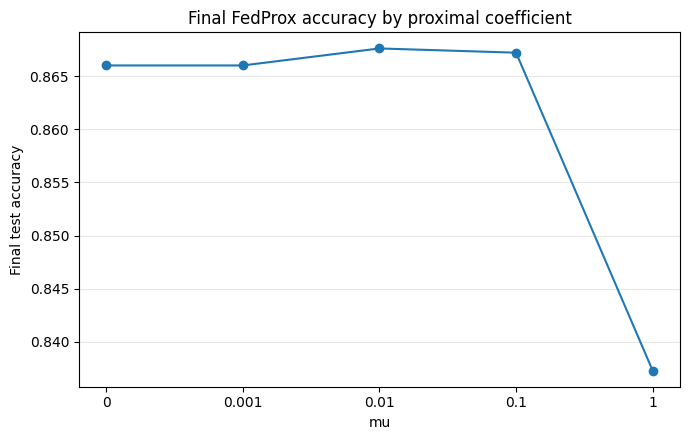

In [22]:
if len(summary_df):
    plot_df = summary_df.sort_values("mu").reset_index(drop=True)
    x = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(x, plot_df["final_accuracy"], marker="o")

    ax.set_xticks(x)
    ax.set_xticklabels([f"{mu:g}" for mu in plot_df["mu"]])
    ax.set_xlabel("mu")
    ax.set_ylabel("Final test accuracy")
    ax.set_title("Final FedProx accuracy by proximal coefficient")
    ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "final_accuracy_vs_mu.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("No summary table is available for plotting.")


## 17. Research Interpretation

Interpretation should be based on the completed histories and summary table. The core comparisons are whether any $\mu>0$ condition improves over the $\mu=0$ control, whether performance changes smoothly with $\mu$, and whether excessive proximal strength harms learning.

Any claim about client drift should remain an interpretation of optimization behavior unless update norms or update-alignment diagnostics are measured directly.


In [23]:
if len(summary_df) and (summary_df["mu"] == 0.0).any():
    control = summary_df.loc[summary_df["mu"] == 0.0].iloc[0]
    best = summary_df.sort_values("final_accuracy", ascending=False).iloc[0]

    interpretation_df = summary_df[[
        "mu",
        "final_loss",
        "final_accuracy",
        "round_to_70",
        "round_to_80",
        "round_to_90",
    ]].copy()
    interpretation_df["accuracy_delta_vs_mu0"] = (
        interpretation_df["final_accuracy"] - float(control["final_accuracy"])
    )

    display(interpretation_df)

    print(f"Control final accuracy (mu=0): {control['final_accuracy']:.4f}")
    print(f"Best observed final accuracy: mu={best['mu']:g}, accuracy={best['final_accuracy']:.4f}")
elif len(summary_df):
    display(summary_df)
    print("The mu=0 control is not available, so improvement over FedAvg cannot be assessed yet.")
else:
    print("Run or restore the mu sweep before drawing experimental conclusions.")


,mu,final_loss,final_accuracy,round_to_70,round_to_80,round_to_90,accuracy_delta_vs_mu0
0,0.000,0.407260,0.8660,3,7,NaN,0.0000
1,0.001,0.406731,0.8660,3,6,NaN,0.0000
2,0.010,0.402684,0.8676,3,5,NaN,0.0016
3,0.100,0.405571,0.8672,3,5,NaN,0.0012
4,1.000,0.506573,0.8373,5,8,NaN,-0.0287


Control final accuracy (mu=0): 0.8660
Best observed final accuracy: mu=0.01, accuracy=0.8676


## 18. Next Experiments

Natural extensions are an $\alpha 	imes \mu$ study, client-update norm diagnostics, pairwise update cosine similarity, varying local epochs $E$, adaptive $\mu$, and comparison with SCAFFOLD.


## 19. Artifact Check


In [24]:
artifact_rows = [
    {"artifact": "configuration", "path": RESULT_DIR / "config.json"},
    {"artifact": "source partition", "path": CLIENT_INDICES_PATH},
    {"artifact": "label distribution", "path": fedprox_distribution_path},
    {"artifact": "summary", "path": RESULT_DIR / "summary.csv"},
    {"artifact": "figures", "path": FIGURE_DIR},
]

for mu in CFG.mu_values:
    artifact_rows.append({
        "artifact": f"history mu={mu:g}",
        "path": history_path_for_mu(mu),
    })

artifact_df = pd.DataFrame(artifact_rows)
artifact_df["exists"] = artifact_df["path"].map(lambda path: Path(path).exists())
artifact_df["path"] = artifact_df["path"].map(str)
artifact_df


,artifact,path,exists
0,configuration,/kaggle/working/federated-learning-under-heter...,True
1,source partition,/kaggle/working/federated-learning-under-heter...,True
2,label distribution,/kaggle/working/federated-learning-under-heter...,True
3,summary,/kaggle/working/federated-learning-under-heter...,True
4,figures,/kaggle/working/federated-learning-under-heter...,True
5,history mu=0,/kaggle/working/federated-learning-under-heter...,True
6,history mu=0.001,/kaggle/working/federated-learning-under-heter...,True
7,history mu=0.01,/kaggle/working/federated-learning-under-heter...,True
8,history mu=0.1,/kaggle/working/federated-learning-under-heter...,True
9,history mu=1,/kaggle/working/federated-learning-under-heter...,True
